In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [10]:

train_m = pd.read_csv("tourney_train_m.csv")
test_m = pd.read_csv("tourney_test_m.csv")
val_m = pd.read_csv("tourney_val_m.csv")

train_w = pd.read_csv("tourney_train_w.csv")
test_w = pd.read_csv("tourney_test_w.csv")
val_w = pd.read_csv("tourney_val_w.csv")

In [11]:
X = train_m.drop(columns=['Is1Winner','1TeamID','2TeamID','Season'])
y = train_m['Is1Winner']

In [12]:
# Logistic Regression

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

param_grid_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X, y)

print("LR best params:", grid_lr.best_params_)
print("LR best score:", grid_lr.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
LR best params: {'model__C': 0.001, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
LR best score: 0.6836501901140685


In [13]:
# Random Forest

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X, y)

print("RF best params:", grid_rf.best_params_)
print("RF best score:", grid_rf.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
RF best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
RF best score: 0.6965779467680608


In [14]:
# XGBoost

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid_xgb = {
    'n_estimators': [300, 600],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X, y)

print("XGB best params:", grid_xgb.best_params_)
print("XGB best score:", grid_xgb.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
XGB best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 600, 'subsample': 0.8}
XGB best score: 0.6904942965779467


In [15]:
# lightgbm

lgb = LGBMClassifier(random_state=42)

param_grid_lgb = {
    'n_estimators': [300, 600],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 63],
    'subsample': [0.8, 1.0]
}

grid_lgb = GridSearchCV(
    lgb,
    param_grid_lgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_lgb.fit(X, y)

print("LGB best params:", grid_lgb.best_params_)
print("LGB best score:", grid_lgb.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[LightGBM] [Info] Number of positive: 544, number of negative: 508
[LightGBM] [Info] Number of positive: 544, number of negative: 508
[LightGBM] [Info] Number of positive: 544, number of negative: 508
[LightGBM] [Info] Number of positive: 544, number of negative: 508
[LightGBM] [Info] Number of positive: 544, number of negative: 508
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31528
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31462
[LightGBM] [Info] Number of data points in the train set: 1052, number of used features: 171
[LightGBM] [Info] Number of data points in the train set: 1052, number of used features: 171
[LightGBM] [Info] Auto-

In [16]:
print("LR:", grid_lr.best_score_)
print("RF:", grid_rf.best_score_)
print("XGB:", grid_xgb.best_score_)
print("LGB:", grid_lgb.best_score_)

LR: 0.6836501901140685
RF: 0.6965779467680608
XGB: 0.6904942965779467
LGB: 0.6897338403041825


In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

def evaluate_model(model, X_val, y_val):
    """
    Ocena już wytrenowanego modelu.
    Rysuje ROC curve i confusion matrix.
    """

    # Predykcje klas
    y_pred = model.predict(X_val)

    # Prawdopodobieństwa do ROC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
    else:
        y_prob = model.decision_function(X_val)

    # Metryki
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)

    print("Accuracy:", acc)
    print("ROC-AUC:", auc)
    print("\nClassification report:\n")
    print(classification_report(y_val, y_pred))

    # ===== ROC Curve =====
    fpr, tpr, _ = roc_curve(y_val, y_prob)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.show()

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_val, y_pred)

    plt.figure()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("Confusion Matrix")
    plt.show()

    return acc, auc

In [18]:
X_val = val_m.drop(columns=['Is1Winner','1TeamID','2TeamID','Season'])
y_val = val_m['Is1Winner']

Accuracy: 0.7019011406844107
ROC-AUC: 0.7885965724872627

Classification report:

              precision    recall  f1-score   support

           0       0.70      0.66      0.68       635
           1       0.70      0.74      0.72       680

    accuracy                           0.70      1315
   macro avg       0.70      0.70      0.70      1315
weighted avg       0.70      0.70      0.70      1315



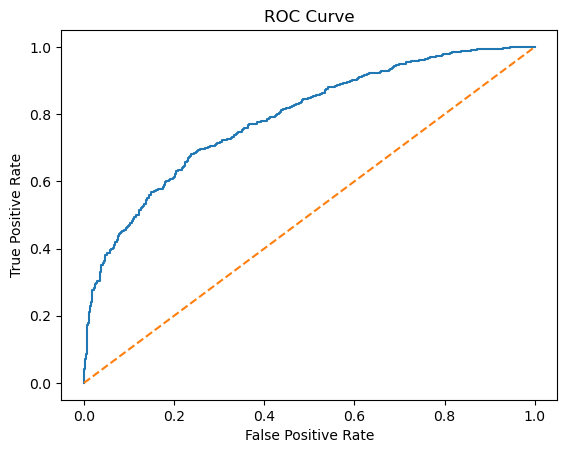

<Figure size 640x480 with 0 Axes>

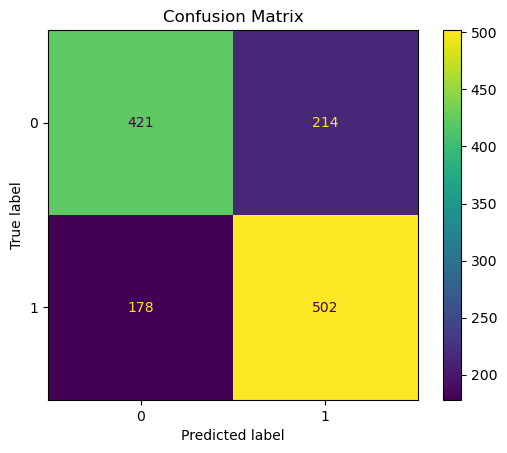

(0.7019011406844107, 0.7885965724872627)

In [20]:
evaluate_model(grid_lr, X, y)


Accuracy: 0.7761194029850746
ROC-AUC: 0.8562271062271062

Classification report:

              precision    recall  f1-score   support

           0       0.71      0.79      0.75        28
           1       0.83      0.77      0.80        39

    accuracy                           0.78        67
   macro avg       0.77      0.78      0.77        67
weighted avg       0.78      0.78      0.78        67



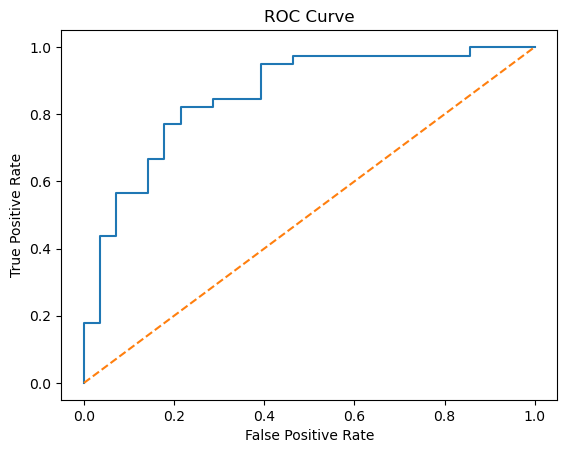

<Figure size 640x480 with 0 Axes>

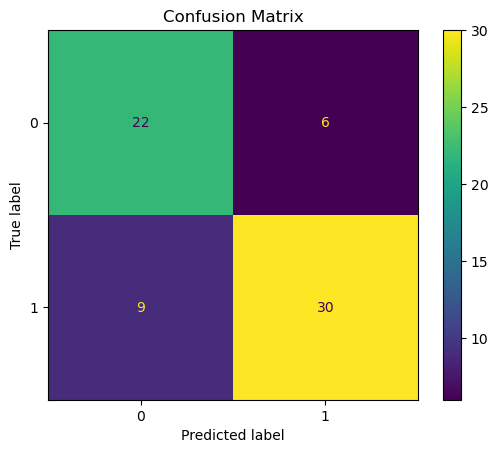

(0.7761194029850746, 0.8562271062271062)

In [22]:
evaluate_model(grid_rf, X_val, y_val)

Accuracy: 0.7910447761194029
ROC-AUC: 0.8772893772893773

Classification report:

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.80      0.85      0.82        39

    accuracy                           0.79        67
   macro avg       0.79      0.78      0.78        67
weighted avg       0.79      0.79      0.79        67



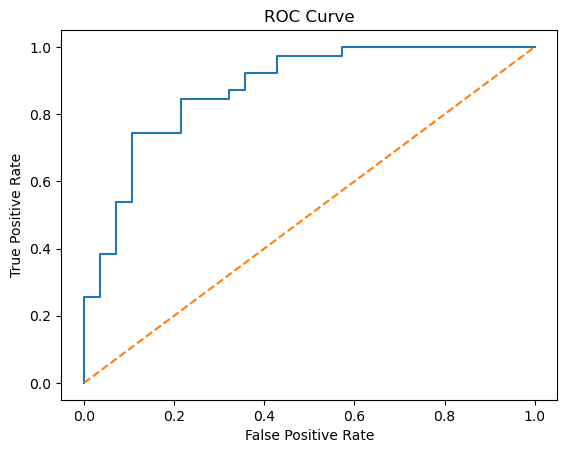

<Figure size 640x480 with 0 Axes>

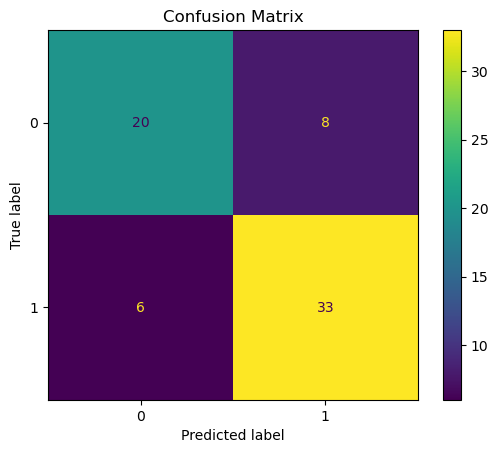

(0.7910447761194029, 0.8772893772893773)

In [24]:
evaluate_model(grid_xgb, X_val, y_val)